In [1]:
!pip install terratorch

  Using cached terratorch-1.0.2-py3-none-any.whl.metadata (10 kB)
  Using cached torch-2.7.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached torchvision-0.22.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached albumentations-1.4.6-py3-none-any.whl.metadata (37 kB)
  Using cached albucore-0.0.16-py3-none-any.whl.metadata (3.1 kB)
  Using cached torchmetrics-1.7.1-py3-none-any.whl.metadata (21 kB)
  Using cached geopandas-1.0.1-py3-none-any.whl.metadata (2.2 kB)
  Using cached lightly-1.5.20-py3-none-any.whl.metadata (37 kB)
  Using cached jsonargparse-4.35.0-py3-none-any.whl.metadata (12 kB)
  Using cached h5py-3.13.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.5 kB)
  Using cached mlflow-2.22.0-py3-none-any.whl.metadata (30 kB)
  Using cached lightning-2.5.1.post0-py3-none-any.whl.metadata (39 kB)
  Using cached segmentation_models_pytorch-0.4.0-py3-none-any.whl.metadata (32 kB)
  Using cached pytest-8.3.5-py3-none-a

In [2]:
from pathlib import Path

import torch
import rioxarray as rxr
from huggingface_hub import hf_hub_download
from terratorch.registry import BACKBONE_REGISTRY

# Select device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

## Patch Extraction Around Label Points 

In [31]:
import xarray as xr
import rioxarray

ds = xr.open_dataset("./data_FM/s2/s2_2024.nc", engine="h5netcdf")

# attach CRS if not already present
if not ds.rio.crs:
    ds = ds.rio.write_crs("EPSG:3832")

ds

<xarray.Dataset> Size: 53GB
Dimensions:          (time: 1, y: 19200, x: 28800)
Coordinates:
  * y                (y) float64 154kB -1.888e+06 -1.888e+06 ... -2.08e+06
  * x                (x) float64 230kB 2.952e+06 2.952e+06 ... 3.24e+06 3.24e+06
    spatial_ref      int32 4B ...
  * time             (time) datetime64[ns] 8B 2024-01-01
Data variables:
    COASTAL_AEROSOL  (time, y, x) float64 4GB ...
    BLUE             (time, y, x) float64 4GB ...
    GREEN            (time, y, x) float64 4GB ...
    RED              (time, y, x) float64 4GB ...
    RED_EDGE_1       (time, y, x) float64 4GB ...
    RED_EDGE_2       (time, y, x) float64 4GB ...
    RED_EDGE_3       (time, y, x) float64 4GB ...
    NIR_BROAD        (time, y, x) float64 4GB ...
    NIR_NARROW       (time, y, x) float64 4GB ...
    CIRRUS           (time, y, x) float64 4GB ...
    SWIR_1           (time, y, x) float64 4GB ...
    SWIR_2           (time, y, x) float64 4GB ...

In [4]:
import pandas as pd
points = pd.read_csv("./data_FM/label/label.csv")  

In [15]:
import geopandas as gpd
from shapely.geometry import Point

# build GeoDataFrame
gdf = gpd.GeoDataFrame(points, geometry=gpd.points_from_xy(points.lon, points.lat), crs="EPSG:4326")

# reproject to match S2 CRS
gdf = gdf.to_crs(ds.rio.crs)

X, Y = [], []
patch_size = 32
half = patch_size // 2

for _, row in gdf.iterrows():
    label = row["class_id"]
    x = row.geometry.x
    y = row.geometry.y
    
    # find nearest pixel indices
    ref_band = ds["RED"]
    x_res = float((ref_band.x[1] - ref_band.x[0]).item())
    y_res = float((ref_band.y[1] - ref_band.y[0]).item())
    
    x0 = float(ref_band.x[0].item())
    y0 = float(ref_band.y[0].item())

    px = int((x - x0) / x_res)
    py = int((y - y0) / y_res)
        
    # extract patch around the point
    patch = ds.isel(
        x=slice(px-half, px+half),
        y=slice(py-half, py+half),
        time=0
    ).to_array().transpose("y", "x", "variable").values

    if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
        X.append(patch)
        Y.append(label)
    
# stack final dataset
X = np.stack(X)
Y = np.array(Y)
print("Final dataset:", X.shape, Y.shape)



Final dataset: (7621, 32, 32, 12) (7621,)


Class_id : 1


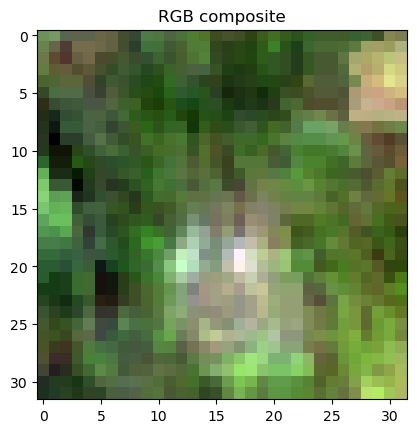

In [41]:
import matplotlib.pyplot as plt
import numpy as np

idx = 1

rgb = X[idx, :, :, [1, 2, 3]]
rgb = np.transpose(rgb, (1, 2, 0))
rgb_norm = (rgb - rgb.min(axis=(0,1))) / (rgb.max(axis=(0,1)) - rgb.min(axis=(0,1)))


print(f"Class_id : {Y[idx]}")

plt.imshow(rgb_norm)
plt.title("RGB composite")
plt.show()


In [47]:
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_origin
from sklearn.model_selection import train_test_split

# ----------------------------
# Configuration
# ----------------------------
patch_size = 32
half = patch_size // 2
band_order = [
    "COASTAL_AEROSOL", "BLUE", "GREEN", "RED", 
    "RED_EDGE_1", "RED_EDGE_2", "RED_EDGE_3",
    "NIR_BROAD", "NIR_NARROW", "CIRRUS", "SWIR_1", "SWIR_2"
]

base_path = "./data_FM/s2/patch"
folders = ["train", "validation", "test"]

# Make directories
for f in folders:
    os.makedirs(os.path.join(base_path, f, "X"), exist_ok=True)
    os.makedirs(os.path.join(base_path, f, "y"), exist_ok=True)

# ----------------------------
# Split data
# ----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

splits = {
    "train": (X_train, y_train),
    "validation": (X_val, y_val),
    "test": (X_test, y_test)
}

# ----------------------------
# Function to save patches as GeoTIFF
# ----------------------------
def save_patches_geotiff(X_data, y_data, folder, ref_ds, band_order):
    rows = []
    for i in range(X_data.shape[0]):
        patch = X_data[i]  # shape: (32,32,12)
        label = y_data[i]

        # Transform: assumes the patch is aligned with top-left of the raster
        transform = from_origin(
            ref_ds.x[0], ref_ds.y[0], 
            ref_ds.x[1] - ref_ds.x[0], ref_ds.y[1] - ref_ds.y[0]
        )

        # rasterio expects (bands, height, width)
        patch_tif = np.transpose(patch, (2, 0, 1))

        out_file = os.path.join(base_path, folder, "X", f"patch_{i}.tif")
        with rasterio.open(
            out_file,
            'w',
            driver='GTiff',
            height=patch_tif.shape[1],
            width=patch_tif.shape[2],
            count=patch_tif.shape[0],
            dtype=patch_tif.dtype,
            crs=ref_ds.rio.crs,
            transform=transform
        ) as dst:
            dst.write(patch_tif)

        rows.append({"patch_file": out_file, "label": label-1})

    # Save CSV for labels
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(base_path, folder, "y", "labels.csv"), index=False)

# ----------------------------
# Save all splits
# ----------------------------
for split_name, (X_split, y_split) in splits.items():
    save_patches_geotiff(X_split, y_split, split_name, ds, band_order)

print("All patches saved as GeoTIFF with labels CSV!")



All patches saved as GeoTIFF with labels CSV!


## Model

In [4]:
from terratorch.registry import BACKBONE_REGISTRY

for source_name, source in BACKBONE_REGISTRY._sources.items():
    print(f"Source: {source_name}")


Source: terratorch
Source: timm


In [41]:
import pandas as pd
import pytorch_lightning as pl
from omegaconf import OmegaConf
from terratorch.datamodules import GenericMultiModalDataModule
from terratorch.tasks import ClassificationTask
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import RichProgressBar, LearningRateMonitor, EarlyStopping
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint


#  Load YAML config
cfg_path = "fiji.yaml"  # replace with your YAML path
cfg = OmegaConf.load(cfg_path)


#  Instantiate DataModule
dm = GenericMultiModalDataModule(**cfg.data.init_args)

#  Instantiate Model / Task
task = ClassificationTask(**cfg.model.init_args)

trainer = pl.Trainer(cfg.trainer)
# Start training
trainer.fit(task.model, datamodule=dm)
  

KeyError: 'Could not instantiate model terramind_v1_base not from any source.'